In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import traceback


In [2]:
current_dir = Path.cwd() # Directory where the notebook/script is running (e.g., energy_price_prediction/)
base_dir = current_dir.parent # Parent directory (main project folder)

stage1_start_date_config = '2020-01-01' # The start_date used for Stage 1 training/prediction
STAGE1_PREDICTIONS_FILENAME = f'stage1_predictions_mw_model_trained_from_{stage1_start_date_config}.csv'
STAGE1_PREDICTIONS_PATH = current_dir / STAGE1_PREDICTIONS_FILENAME
PRICE_DATA_PATH = base_dir / 'datasets' / 'energy_price' / 'nl_wholesale_electricity_price_data_hourly.csv'

FINAL_MODEL_SAVE_PATH = current_dir / 'final_xgboost_price_model.json'


In [3]:
TARGET_COL = 'Price (EUR/MWhe)' 
STAGE1_FEATURES_TO_USE = ['Predicted_Offshore_MW', 'Predicted_Onshore_MW']
# Define lags for the target variable (price) to create as features (in hours)
PRICE_LAGS = [1, 2, 3, 6, 12, 24]



In [4]:
# Define the size of the test set (e.g., number of hours or days)
TEST_SET_DAYS = 30
TEST_SET_PERIODS = TEST_SET_DAYS * 24 



In [5]:
#parameters for the XGBoost
XGB_PARAMS = {
    'objective': 'reg:squarederror', # Regression task
    'eval_metric': 'rmse',           # Evaluation metric
    'n_estimators': 1000,            # Max number of boosting rounds (trees)
    'learning_rate': 0.016614446639290674, # Step size shrinkage
    'max_depth': 7,                  # Maximum depth of a tree
    'subsample': 0.7,                # Fraction of samples used per boosting round
    'colsample_bytree': 1.0,         # Fraction of features used per boosting round
    'gamma': 4.488085779109953,      # Minimum loss reduction required to make a split
    'reg_alpha': 0.16648167479417808, # L1 regularization term on weights
    'reg_lambda': 3.7552687205045977e-06, # L2 regularization term on weights
    'n_jobs': -1,                    # Use all available CPU cores
    'early_stopping_rounds': 50,     # Stop if eval metric doesn't improve for 50 rounds
    'random_state': 99
}


In [6]:
# Ensure 'Timestamp (UTC)' is parsed as datetime and set as index
stage1_preds_df = pd.read_csv(
    STAGE1_PREDICTIONS_PATH,
    index_col='Timestamp (UTC)',
    parse_dates=True
)
# Ensure index is timezone-aware (UTC)
if stage1_preds_df.index.tz is None:
    stage1_preds_df.index = stage1_preds_df.index.tz_localize('UTC')
else:
    stage1_preds_df.index = stage1_preds_df.index.tz_convert('UTC')

print(f"Loaded Stage 1 predictions: {stage1_preds_df.shape}")
display(stage1_preds_df.head(3))
print(stage1_preds_df.info())

# Load Price Data
price_df = pd.read_csv(
    PRICE_DATA_PATH,
    index_col='Datetime (UTC)', 
    parse_dates=True
)
 # Ensure index is timezone-aware (UTC)
if price_df.index.tz is None:
    price_df.index = price_df.index.tz_localize('UTC')
else:
    price_df.index = price_df.index.tz_convert('UTC')

price_df = price_df[[TARGET_COL]]

print(f"\nLoaded Price data: {price_df.shape}")
display(price_df.head(3))
print(price_df.info())

Loaded Stage 1 predictions: (9190, 2)


,Predicted_Offshore_MW,Predicted_Onshore_MW
Timestamp (UTC),,
2024-03-14 03:00:00+00:00,3205.506199,1575.157746
2024-03-14 04:00:00+00:00,3069.610038,1569.232811
2024-03-14 05:00:00+00:00,2818.686732,1482.163789


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9190 entries, 2024-03-14 03:00:00+00:00 to 2025-04-01 00:00:00+00:00
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Predicted_Offshore_MW  9190 non-null   float64
 1   Predicted_Onshore_MW   9190 non-null   float64
dtypes: float64(2)
memory usage: 215.4 KB
None

Loaded Price data: (89801, 1)


,Price (EUR/MWhe)
Datetime (UTC),
2015-01-01 00:00:00+00:00,36.56
2015-01-01 01:00:00+00:00,36.56
2015-01-01 02:00:00+00:00,36.56


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 89801 entries, 2015-01-01 00:00:00+00:00 to 2025-03-30 20:00:00+00:00
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price (EUR/MWhe)  89801 non-null  float64
dtypes: float64(1)
memory usage: 1.4 MB
None


In [7]:
# Merge based on the timestamp index.
merged_df = stage1_preds_df.merge(
    price_df,
    left_index=True,
    right_index=True,
    how='inner' # Keep only times where BOTH predictions and price exist
)

print(f"Shape after merging: {merged_df.shape}")

# Check for missing values (should be none with 'inner')
missing_vals = merged_df.isnull().sum().sum()
if missing_vals > 0:
    merged_df.dropna(inplace=True)

merged_df.sort_index(inplace=True)

display(merged_df.head())
display(merged_df.tail())
print(merged_df.info())

Shape after merging: (9158, 3)


,Predicted_Offshore_MW,Predicted_Onshore_MW,Price (EUR/MWhe)
2024-03-14 03:00:00+00:00,3205.506199,1575.157746,54.65
2024-03-14 04:00:00+00:00,3069.610038,1569.232811,60.02
2024-03-14 05:00:00+00:00,2818.686732,1482.163789,71.42
2024-03-14 06:00:00+00:00,2856.057539,1553.750631,87.00
2024-03-14 07:00:00+00:00,2907.658909,1554.390764,81.99


,Predicted_Offshore_MW,Predicted_Onshore_MW,Price (EUR/MWhe)
2025-03-30 16:00:00+00:00,2934.375842,1196.037579,14.41
2025-03-30 17:00:00+00:00,2943.729687,1158.960589,60.83
2025-03-30 18:00:00+00:00,2965.707137,1148.435152,62.70
2025-03-30 19:00:00+00:00,3013.282218,1159.775294,65.00
2025-03-30 20:00:00+00:00,3522.122415,1172.800633,61.71


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9158 entries, 2024-03-14 03:00:00+00:00 to 2025-03-30 20:00:00+00:00
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Predicted_Offshore_MW  9158 non-null   float64
 1   Predicted_Onshore_MW   9158 non-null   float64
 2   Price (EUR/MWhe)       9158 non-null   float64
dtypes: float64(3)
memory usage: 286.2 KB
None


In [8]:
features_df = merged_df.copy()

# Time Features
print("Creating time features...")
features_df['hour'] = features_df.index.hour
features_df['dayofweek'] = features_df.index.dayofweek
features_df['dayofyear'] = features_df.index.dayofyear
features_df['month'] = features_df.index.month
features_df['year'] = features_df.index.year
features_df['weekofyear'] = features_df.index.isocalendar().week.astype(int)

# Lagged Price Features
print(f"Creating lagged price features for lags: {PRICE_LAGS} hours...")
for lag in PRICE_LAGS:
    features_df[f'price_lag_{lag}h'] = features_df[TARGET_COL].shift(lag)

# Handle NaNs created by lagging
features_df.dropna(inplace=True)

display(features_df.head())
display(features_df.tail())
print(features_df.info())

Creating time features...
Creating lagged price features for lags: [1, 2, 3, 6, 12, 24] hours...


,Predicted_Offshore_MW,Predicted_Onshore_MW,Price (EUR/MWhe),hour,dayofweek,dayofyear,month,year,weekofyear,price_lag_1h,price_lag_2h,price_lag_3h,price_lag_6h,price_lag_12h,price_lag_24h
2024-03-15 03:00:00+00:00,3705.604651,1696.431309,42.22,3,4,75,3,2024,11,42.33,44.47,45.47,59.53,65.99,54.65
2024-03-15 04:00:00+00:00,3666.028217,1703.758523,41.52,4,4,75,3,2024,11,42.22,42.33,44.47,50.91,85.64,60.02
2024-03-15 05:00:00+00:00,3639.300401,1731.841579,58.49,5,4,75,3,2024,11,41.52,42.22,42.33,47.89,102.35,71.42
2024-03-15 06:00:00+00:00,3666.615653,1733.233601,66.47,6,4,75,3,2024,11,58.49,41.52,42.22,45.47,89.92,87.00
2024-03-15 07:00:00+00:00,3611.699389,1820.919678,67.42,7,4,75,3,2024,11,66.47,58.49,41.52,44.47,73.62,81.99


,Predicted_Offshore_MW,Predicted_Onshore_MW,Price (EUR/MWhe),hour,dayofweek,dayofyear,month,year,weekofyear,price_lag_1h,price_lag_2h,price_lag_3h,price_lag_6h,price_lag_12h,price_lag_24h
2025-03-30 16:00:00+00:00,2934.375842,1196.037579,14.41,16,6,89,3,2025,13,0.07,-4.01,-15.34,-33.00,0.00,90.49
2025-03-30 17:00:00+00:00,2943.729687,1158.960589,60.83,17,6,89,3,2025,13,14.41,0.07,-4.01,-33.00,-0.03,136.70
2025-03-30 18:00:00+00:00,2965.707137,1148.435152,62.70,18,6,89,3,2025,13,60.83,14.41,0.07,-33.00,-0.01,143.96
2025-03-30 19:00:00+00:00,3013.282218,1159.775294,65.00,19,6,89,3,2025,13,62.70,60.83,14.41,-15.34,-0.04,114.77
2025-03-30 20:00:00+00:00,3522.122415,1172.800633,61.71,20,6,89,3,2025,13,65.00,62.70,60.83,-4.01,-3.47,93.81


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9134 entries, 2024-03-15 03:00:00+00:00 to 2025-03-30 20:00:00+00:00
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Predicted_Offshore_MW  9134 non-null   float64
 1   Predicted_Onshore_MW   9134 non-null   float64
 2   Price (EUR/MWhe)       9134 non-null   float64
 3   hour                   9134 non-null   int32  
 4   dayofweek              9134 non-null   int32  
 5   dayofyear              9134 non-null   int32  
 6   month                  9134 non-null   int32  
 7   year                   9134 non-null   int32  
 8   weekofyear             9134 non-null   int64  
 9   price_lag_1h           9134 non-null   float64
 10  price_lag_2h           9134 non-null   float64
 11  price_lag_3h           9134 non-null   float64
 12  price_lag_6h           9134 non-null   float64
 13  price_lag_12h          9134 non-null   float64
 14  price_la

In [9]:
# Calculate the split index
split_index = len(features_df) - TEST_SET_PERIODS

# Split chronologically
train_df = features_df.iloc[:split_index]
test_df = features_df.iloc[split_index:]

print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape:  {test_df.shape}")
print(f"Training set time range: {train_df.index.min()} to {train_df.index.max()}")
print(f"Testing set time range:  {test_df.index.min()} to {test_df.index.max()}")

assert train_df.index.max() < test_df.index.min()

Training set shape: (8414, 15)
Testing set shape:  (720, 15)
Training set time range: 2024-03-15 03:00:00+00:00 to 2025-02-28 18:00:00+00:00
Testing set time range:  2025-02-28 19:00:00+00:00 to 2025-03-30 20:00:00+00:00


In [10]:
# Define Features (X) and Target (y) 
# Define feature columns (all columns except the target)
feature_cols = [col for col in features_df.columns if col != TARGET_COL]

# Create X and y sets
X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL]
X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL]


In [11]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape},  y_test shape: {y_test.shape}")
print(X_train.columns.tolist())

X_train shape: (8414, 14), y_train shape: (8414,)
X_test shape:  (720, 14),  y_test shape: (720,)
['Predicted_Offshore_MW', 'Predicted_Onshore_MW', 'hour', 'dayofweek', 'dayofyear', 'month', 'year', 'weekofyear', 'price_lag_1h', 'price_lag_2h', 'price_lag_3h', 'price_lag_6h', 'price_lag_12h', 'price_lag_24h']


In [12]:
# Persistence Baseline
persistence_lag_col = 'price_lag_1h'
print("Training XGBoost model...")

model = xgb.XGBRegressor(**XGB_PARAMS)
eval_set = [(X_train, y_train), (X_test, y_test)]

model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=100
)

print("\nXGBoost model training completed.")
print(f"Best Iteration (Number of Trees): {model.best_iteration}")

Training XGBoost model...
[0]	validation_0-rmse:54.15767	validation_1-rmse:46.78587
[100]	validation_0-rmse:15.24874	validation_1-rmse:16.08510
[200]	validation_0-rmse:9.22684	validation_1-rmse:12.82468
[300]	validation_0-rmse:7.66754	validation_1-rmse:12.30791
[400]	validation_0-rmse:6.85020	validation_1-rmse:12.23628
[433]	validation_0-rmse:6.66153	validation_1-rmse:12.27030

XGBoost model training completed.
Best Iteration (Number of Trees): 384


In [13]:
# Prediction & Evaluation 

y_pred = model.predict(X_test)

mae_model = mean_absolute_error(y_test, y_pred)
rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))

y_pred_persistence = X_test[persistence_lag_col]
mae_persistence = mean_absolute_error(y_test, y_pred_persistence)
rmse_persistence = np.sqrt(mean_squared_error(y_test, y_pred_persistence))
print(f"Persistence Baseline (predict P(t)=P(t-1)):")
print(f"  MAE:  {mae_persistence:.3f} EUR/MWh")
print(f"  RMSE: {rmse_persistence:.3f} EUR/MWh")

# 2. Average Baseline
y_pred_average = np.full_like(y_test, fill_value=y_train.mean())
mae_average = mean_absolute_error(y_test, y_pred_average)
rmse_average = np.sqrt(mean_squared_error(y_test, y_pred_average))
print(f"\nAverage Baseline (predict P(t)=mean(P_train)):")
print(f"  MAE:  {mae_average:.3f} EUR/MWh")
print(f"  RMSE: {rmse_average:.3f} EUR/MWh")


results_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'XGBoost': [mae_model, rmse_model],
    'Persistence': [mae_persistence, rmse_persistence],
    'Average': [mae_average, rmse_average]
}).set_index('Metric')

display(results_summary.round(3))



Persistence Baseline (predict P(t)=P(t-1)):
  MAE:  15.179 EUR/MWh
  RMSE: 21.529 EUR/MWh

Average Baseline (predict P(t)=mean(P_train)):
  MAE:  36.865 EUR/MWh
  RMSE: 47.482 EUR/MWh


,XGBoost,Persistence,Average
Metric,,,
MAE,7.942,15.179,36.865
RMSE,12.223,21.529,47.482


In [14]:
# Use the index from y_test (which contains the timestamps)
predictions_output_df = pd.DataFrame({
    'Actual_Price': y_test,      # Actual prices from the test set
    'Predicted_Price': y_pred    # Predicted prices from the model
}, index=y_test.index)

# Define output path 
output_compare_filename = 'price_predictions_vs_actual_test_set.csv'
output_compare_path = current_dir / output_compare_filename

# Save the DataFrame to CSV
try:
    predictions_output_df.to_csv(output_compare_path, index=True) 
    print(f"\n[SUCCESS] Actual vs Predicted prices saved to: {output_compare_path}")
except Exception as e:
    print(f"\n[ERROR] Failed to save predictions comparison CSV: {e}")
    traceback.print_exc() # Print traceback if saving fails




[SUCCESS] Actual vs Predicted prices saved to: /Users/main/Developer/Tempestas/energy_price_prediction/price_predictions_vs_actual_test_set.csv


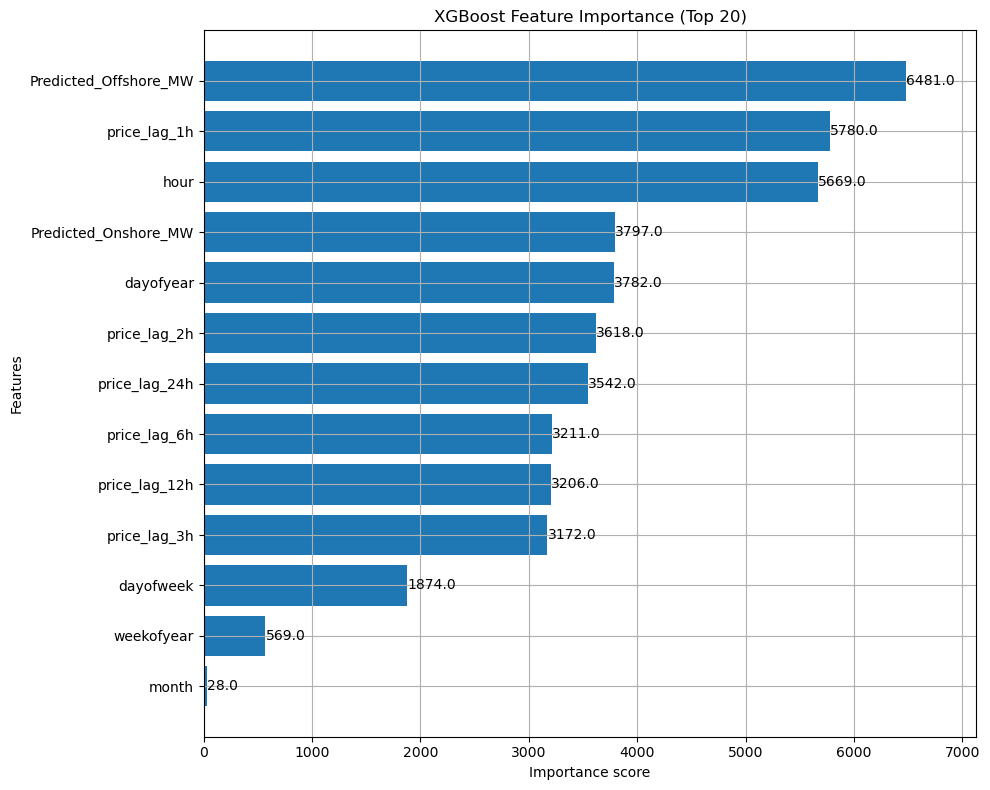


Top 10 Features by Importance:


,Feature,Importance
0,Predicted_Offshore_MW,6481.0
7,price_lag_1h,5780.0
2,hour,5669.0
1,Predicted_Onshore_MW,3797.0
4,dayofyear,3782.0
8,price_lag_2h,3618.0
12,price_lag_24h,3542.0
10,price_lag_6h,3211.0
11,price_lag_12h,3206.0
9,price_lag_3h,3172.0


In [15]:
# FEature importance

fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(model, ax=ax, max_num_features=20, height=0.8, importance_type='weight')
ax.set_title('XGBoost Feature Importance (Top 20)')
plt.tight_layout()
plt.show()

importance_scores = model.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'Feature': importance_scores.keys(),
    'Importance': importance_scores.values()
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features by Importance:")
display(importance_df.head(10))

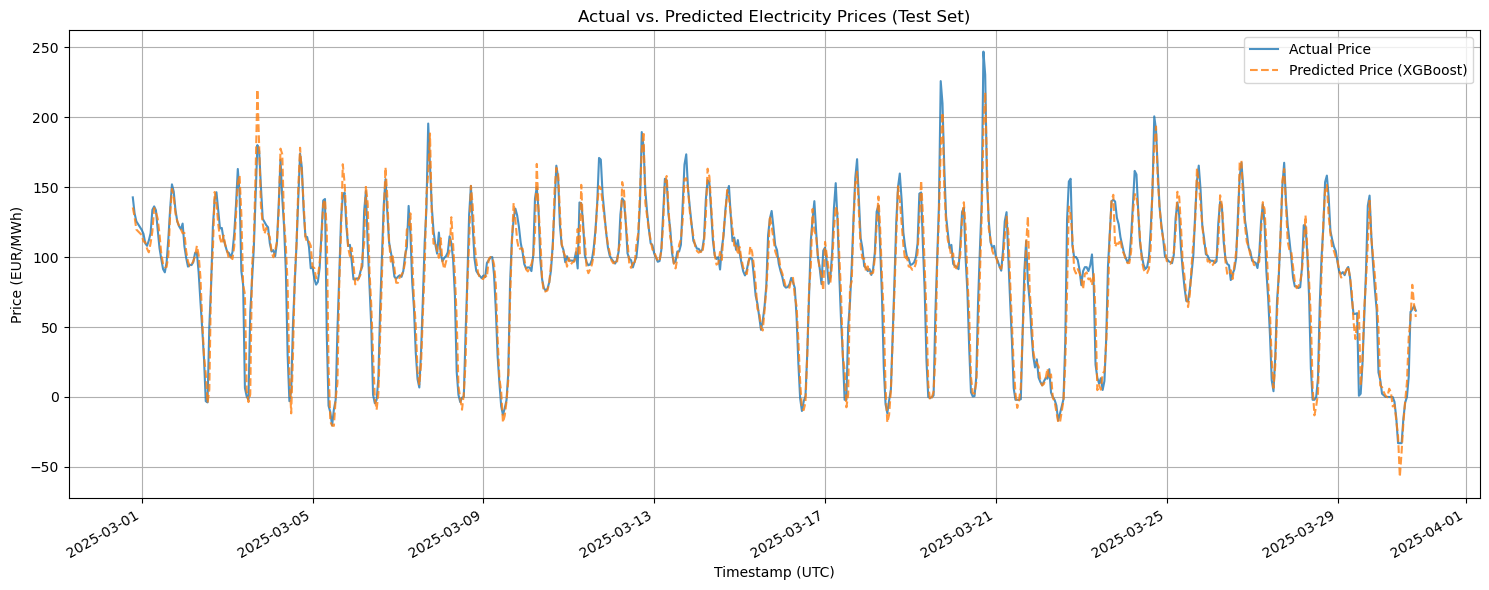

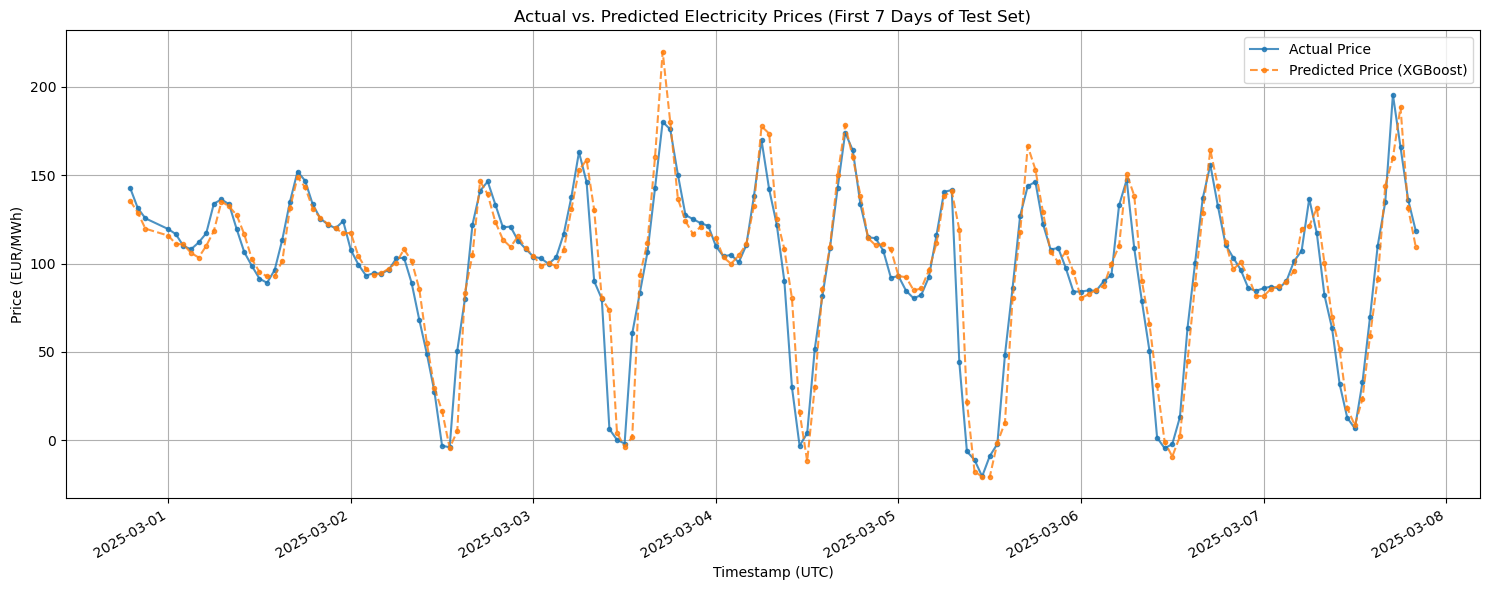

In [16]:
plot_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
}, index=y_test.index)

fig, ax = plt.subplots(figsize=(15, 6))
plot_df['Actual Price'].plot(ax=ax, label='Actual Price', alpha=0.8)
plot_df['Predicted Price'].plot(ax=ax, label='Predicted Price (XGBoost)', linestyle='--', alpha=0.8)
ax.set_title('Actual vs. Predicted Electricity Prices (Test Set)')
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Price (EUR/MWh)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

plot_subset_df = plot_df.head(24 * 7)
fig_subset, ax_subset = plt.subplots(figsize=(15, 6))
plot_subset_df['Actual Price'].plot(ax=ax_subset, label='Actual Price', marker='.', linestyle='-', alpha=0.8)
plot_subset_df['Predicted Price'].plot(ax=ax_subset, label='Predicted Price (XGBoost)', marker='.', linestyle='--', alpha=0.8)
ax_subset.set_title('Actual vs. Predicted Electricity Prices (First 7 Days of Test Set)')
ax_subset.set_xlabel('Timestamp (UTC)')
ax_subset.set_ylabel('Price (EUR/MWh)')
ax_subset.legend()
ax_subset.grid(True)
plt.tight_layout()
plt.show()